# Análise exploratória — Histórico de vendas (Saltim)

Notebook para inspecionar o dataset sintético `vendas.csv` (2023-01-01 a 2026-05-19).

**Fontes:**
- `vendas.csv` — transações (id, date_time, recipe_id, quantity)
- `receitas.csv` — nomes e preços dos produtos finais
- `resumo_diario_vendas.csv` — flags de sazonalidade por dia
- `feriados_recife.csv` — calendário de feriados

## 1. Setup e carga dos dados

In [13]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DATA_DIR = Path(".").resolve()
if not (DATA_DIR / "vendas.csv").exists():
    DATA_DIR = Path("../New").resolve()  # fallback se rodar de data/

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

MESES_PT = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez",
}
DIAS_PT = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]

vendas = pd.read_csv(DATA_DIR / "vendas.csv", parse_dates=["date_time"])
receitas = pd.read_csv(DATA_DIR / "receitas.csv")
resumo_diario = pd.read_csv(DATA_DIR / "resumo_diario_vendas.csv", parse_dates=["date"])
feriados = pd.read_csv(DATA_DIR / "feriados_recife.csv", parse_dates=["data"])

produtos = receitas[receitas["type"] == "PRODUTO_FINAL"][["id", "name", "sale_price"]].copy()
produtos = produtos.rename(columns={"id": "recipe_id", "name": "produto", "sale_price": "preco"})

df = vendas.merge(produtos, on="recipe_id", how="left")
df["data"] = df["date_time"].dt.floor("D")
df["ano"] = df["date_time"].dt.year
df["mes"] = df["date_time"].dt.month
df["dia_semana"] = df["date_time"].dt.weekday
df["hora"] = df["date_time"].dt.hour
df["receita_est"] = df["quantity"] * df["preco"].fillna(0)

print(f"Registros: {len(df):,}")
print(f"Período: {df['date_time'].min()} → {df['date_time'].max()}")
print(f"Produtos distintos: {df['recipe_id'].nunique()}")
df.head()

Registros: 238,582
Período: 2023-01-01 08:27:02 → 2026-05-19 19:55:30
Produtos distintos: 61


,id,date_time,recipe_id,quantity,unit_price,produto,preco,data,ano,mes,dia_semana,hora,receita_est
0,VEN000000001,2023-01-01 08:27:02,REC0101,3,8.0,BRIGADEIRO DE DOCE DE LEITE,4.34,2023-01-01,2023,1,6,8,13.02
1,VEN000000002,2023-01-01 08:29:15,REC0073,2,18.9,GREENTEA PENG SODA,18.90,2023-01-01,2023,1,6,8,37.80
2,VEN000000003,2023-01-01 09:02:09,REC0053,3,36.9,KATSU SANDO SUB,36.90,2023-01-01,2023,1,6,9,110.70
3,VEN000000004,2023-01-01 09:06:14,REC0092,3,21.9,BOWL DE IOGURTE - INDIVIDUAL,21.90,2023-01-01,2023,1,6,9,65.70
4,VEN000000005,2023-01-01 09:26:44,REC0082,2,54.9,RECIFE É UM OVO - BRIOCHE,54.90,2023-01-01,2023,1,6,9,109.80


## 2. Visão geral (KPIs)

In [14]:
kpis = pd.DataFrame({
    "Métrica": [
        "Total de vendas (linhas)",
        "Unidades vendidas",
        "Receita estimada (R$)",
        "Ticket médio (R$/venda)",
        "Itens por venda (média)",
        "Dias com movimento",
    ],
    "Valor": [
        f"{len(df):,}",
        f"{df['quantity'].sum():,}",
        f"R$ {df['receita_est'].sum():,.0f}",
        f"R$ {df['receita_est'].mean():.2f}",
        f"{df['quantity'].mean():.2f}",
        f"{df['data'].nunique():,}",
    ],
})
display(kpis)

por_ano = (
    df.groupby("ano")
    .agg(vendas=("id", "count"), unidades=("quantity", "sum"), receita=("receita_est", "sum"))
    .assign(var_vendas_pct=lambda x: x["vendas"].pct_change() * 100)
)
por_ano

,Métrica,Valor
0,Total de vendas (linhas),"238,582"
1,Unidades vendidas,"621,302"
2,Receita estimada (R$),"R$ 16,295,824"
3,Ticket médio (R$/venda),R$ 68.30
4,Itens por venda (média),2.60
5,Dias com movimento,"1,220"


,vendas,unidades,receita,var_vendas_pct
ano,,,,
2023,58908,153315,4095130.36,NaN
2024,78642,204723,5388875.15,33.499694
2025,70859,184727,4736021.54,-9.896747
2026,30173,78537,2075796.80,-57.418253


## 3. Tendência temporal

Evolução mensal e série diária com média móvel de 7 dias.

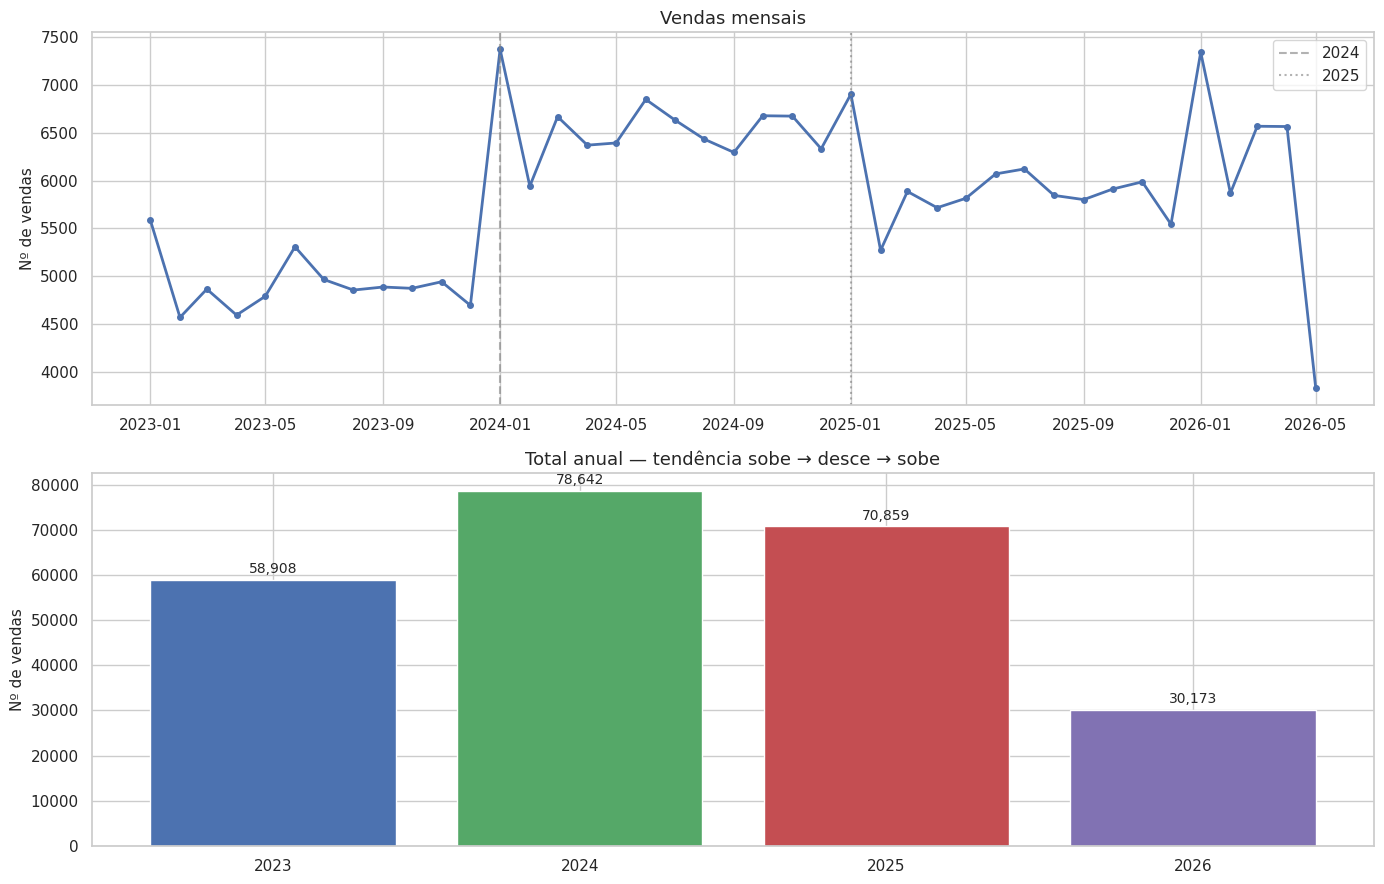

In [15]:
mensal = df.groupby(["ano", "mes"], as_index=False).agg(vendas=("id", "count"))
mensal["periodo"] = pd.to_datetime(
    mensal["ano"].astype(str) + "-" + mensal["mes"].astype(str).str.zfill(2) + "-01"
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

axes[0].plot(mensal["periodo"], mensal["vendas"], marker="o", linewidth=2, markersize=4)
axes[0].set_title("Vendas mensais")
axes[0].set_ylabel("Nº de vendas")
axes[0].axvline(pd.Timestamp("2024-01-01"), color="gray", ls="--", alpha=0.6, label="2024")
axes[0].axvline(pd.Timestamp("2025-01-01"), color="gray", ls=":", alpha=0.6, label="2025")
axes[0].legend()

anual = df.groupby("ano")["id"].count()
cores = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"][: len(anual)]
bars = axes[1].bar(anual.index.astype(str), anual.values, color=cores, edgecolor="white")
axes[1].set_title("Total anual — tendência sobe → desce → sobe")
axes[1].set_ylabel("Nº de vendas")
for bar, val in zip(bars, anual.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 800, f"{val:,}",
                   ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

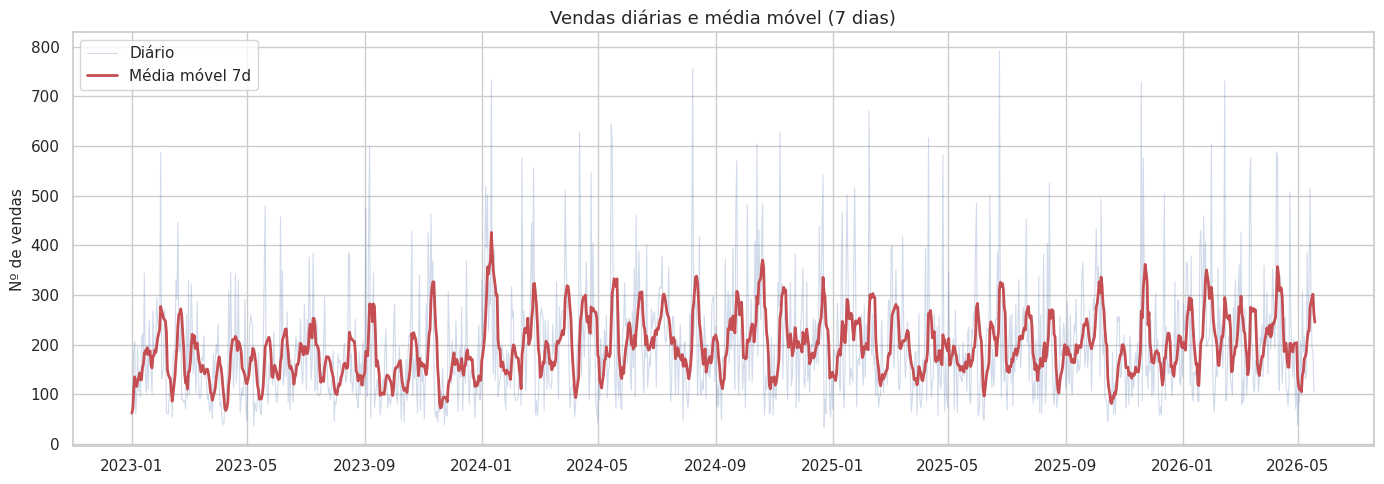

In [16]:
diario = df.groupby("data").agg(vendas=("id", "count")).reset_index()
diario["mm7"] = diario["vendas"].rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(diario["data"], diario["vendas"], alpha=0.25, linewidth=0.8, label="Diário")
ax.plot(diario["data"], diario["mm7"], color="#C44E52", linewidth=2, label="Média móvel 7d")
ax.set_title("Vendas diárias e média móvel (7 dias)")
ax.set_ylabel("Nº de vendas")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Sazonalidade semanal e horária

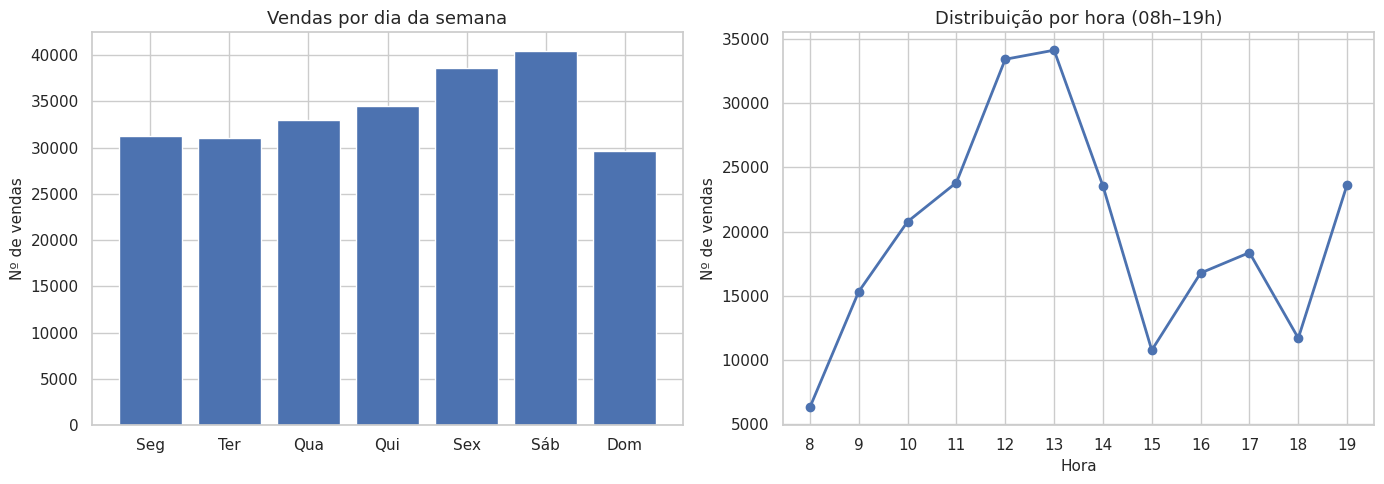

In [17]:
por_dia = df.groupby("dia_semana")["id"].count().reindex(range(7))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(DIAS_PT, por_dia.values, color=sns.color_palette("deep")[0])
axes[0].set_title("Vendas por dia da semana")
axes[0].set_ylabel("Nº de vendas")

por_hora = df.groupby("hora")["id"].count().reindex(range(8, 20), fill_value=0)
axes[1].plot(por_hora.index, por_hora.values, marker="o", linewidth=2)
axes[1].set_title("Distribuição por hora (08h–19h)")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Nº de vendas")
axes[1].set_xticks(range(8, 20))

plt.tight_layout()
plt.show()

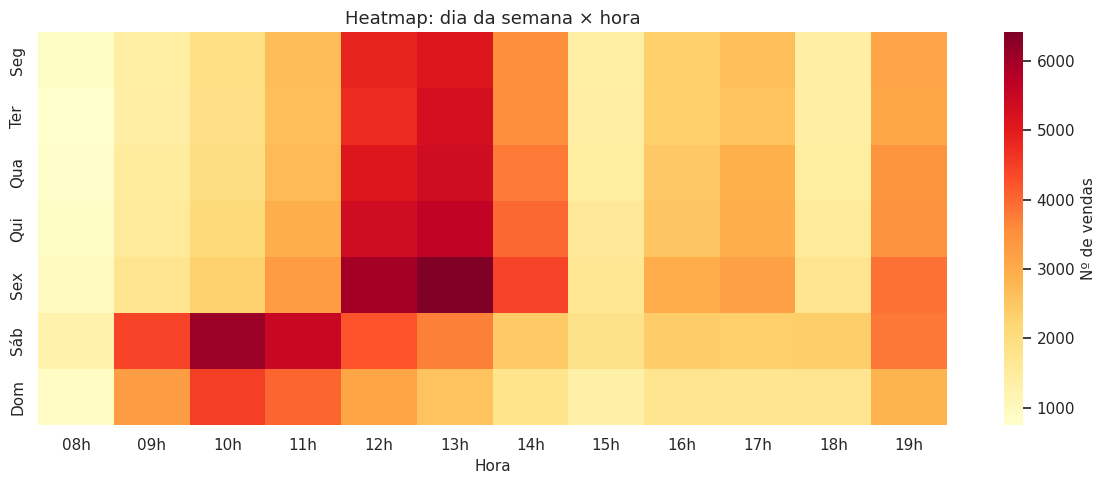

In [18]:
heat = df.groupby(["dia_semana", "hora"])["id"].count().unstack(fill_value=0)
heat = heat.reindex(index=range(7), columns=range(8, 20), fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    heat,
    ax=ax,
    cmap="YlOrRd",
    annot=False,
    fmt="d",
    cbar_kws={"label": "Nº de vendas"},
    yticklabels=DIAS_PT,
    xticklabels=[f"{h:02d}h" for h in range(8, 20)],
)
ax.set_title("Heatmap: dia da semana × hora")
ax.set_xlabel("Hora")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 5. Sazonalidade mensal (comparativo entre anos)

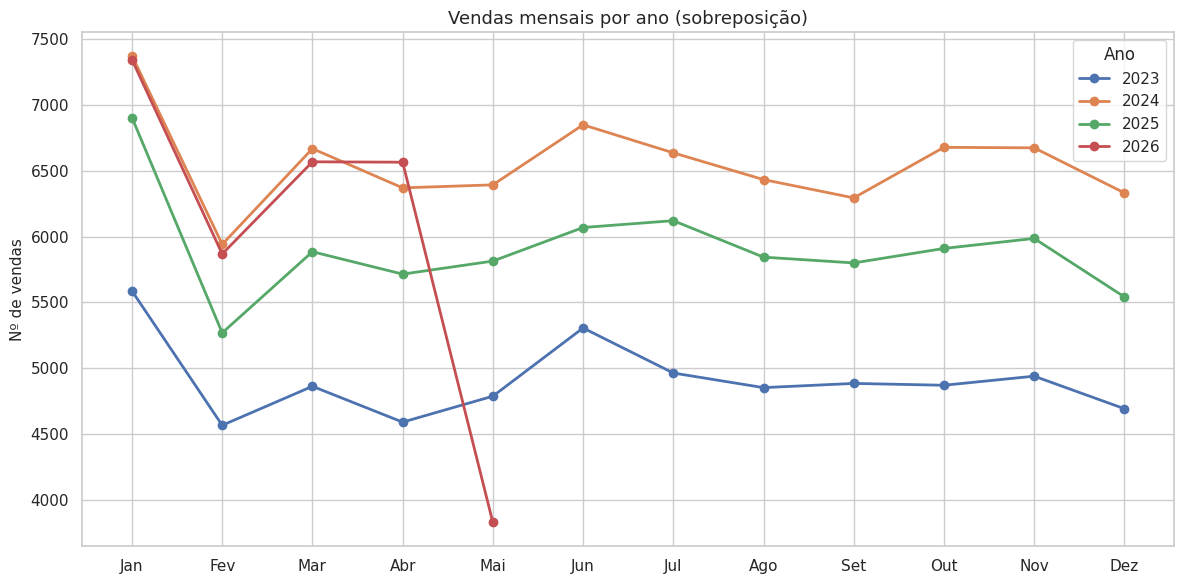

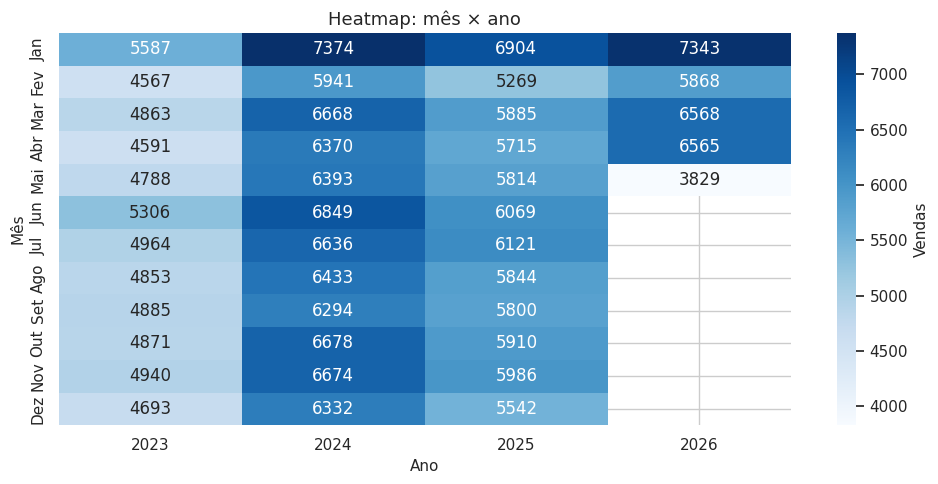

In [19]:
mensal_plot = mensal.copy()
mensal_plot["mes_label"] = mensal_plot["mes"].map(MESES_PT)

fig, ax = plt.subplots(figsize=(12, 6))
for ano in sorted(mensal_plot["ano"].unique()):
  sub = mensal_plot[mensal_plot["ano"] == ano]
  ax.plot(sub["mes"], sub["vendas"], marker="o", label=str(ano), linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([MESES_PT[m] for m in range(1, 13)])
ax.set_title("Vendas mensais por ano (sobreposição)")
ax.set_ylabel("Nº de vendas")
ax.legend(title="Ano")
plt.tight_layout()
plt.show()

pivot_mes = mensal.pivot(index="mes", columns="ano", values="vendas")
pivot_mes.index = pivot_mes.index.map(MESES_PT)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_mes, annot=True, fmt=".0f", cmap="Blues", ax=ax, cbar_kws={"label": "Vendas"})
ax.set_title("Heatmap: mês × ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Mês")
plt.tight_layout()
plt.show()

## 6. Mix de produtos

/tmp/ipykernel_50107/572541036.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_prod, y="produto", x="vendas", ax=axes[0], palette="Blues_r")
/tmp/ipykernel_50107/572541036.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rec, y="produto", x="receita", ax=axes[1], palette="Greens_r")


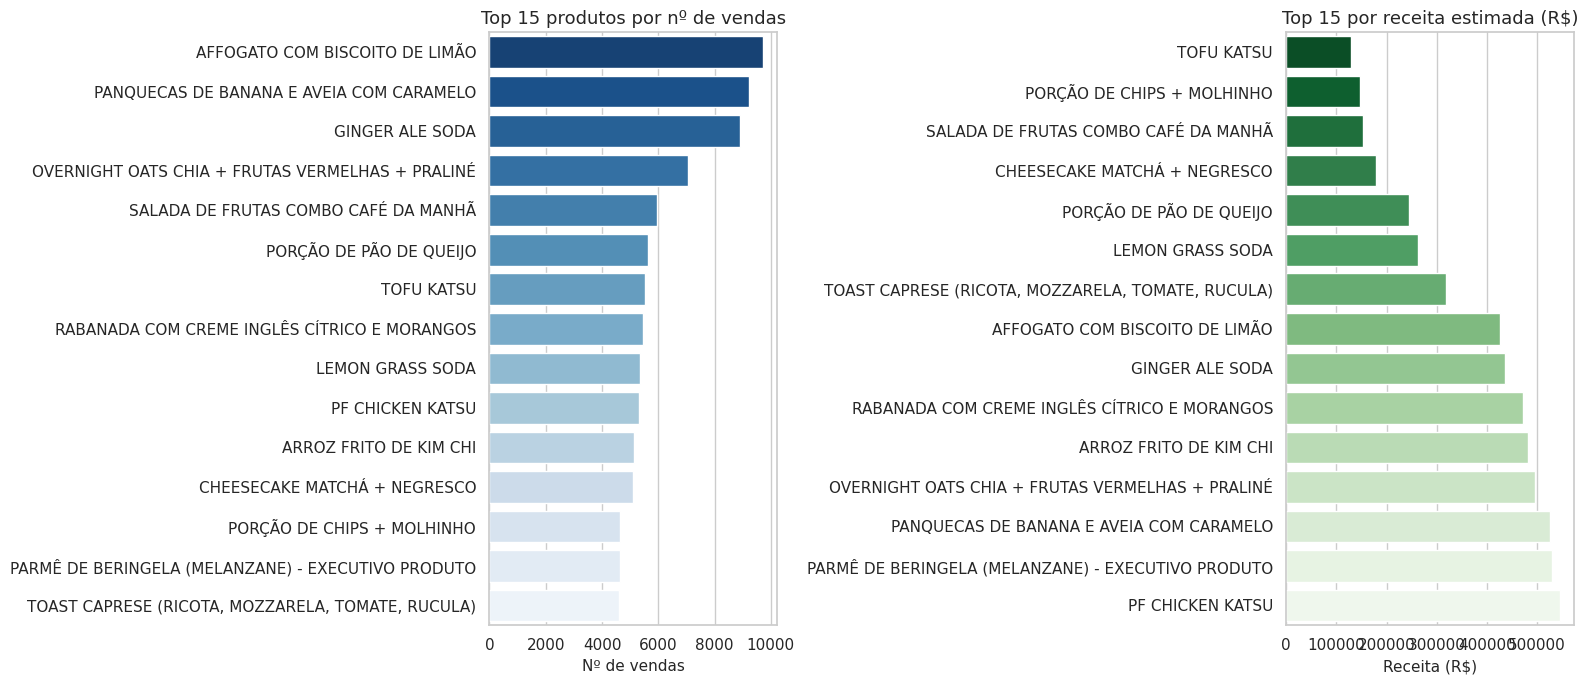

,recipe_id,produto,vendas,unidades,receita
22,REC0067,AFFOGATO COM BISCOITO DE LIMÃO,9739,25283,427282.70
21,REC0066,PANQUECAS DE BANANA E AVEIA COM CARAMELO,9211,23984,525249.60
26,REC0071,GINGER ALE SODA,8904,23133,437213.70
12,REC0057,OVERNIGHT OATS CHIA + FRUTAS VERMELHAS + PRALINÉ,7051,18442,496089.80
33,REC0078,SALADA DE FRUTAS COMBO CAFÉ DA MANHÃ,5948,15416,152618.40
46,REC0091,PORÇÃO DE PÃO DE QUEIJO,5641,14822,244563.00
51,REC0096,TOFU KATSU,5516,14211,129604.32
2,REC0047,RABANADA COM CREME INGLÊS CÍTRICO E MORANGOS,5462,14343,471884.70
25,REC0070,LEMON GRASS SODA,5356,13955,263749.50
13,REC0058,PF CHICKEN KATSU,5312,13698,546550.20


In [20]:
top_prod = (
    df.groupby(["recipe_id", "produto"], as_index=False)
    .agg(vendas=("id", "count"), unidades=("quantity", "sum"), receita=("receita_est", "sum"))
    .sort_values("vendas", ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=top_prod, y="produto", x="vendas", ax=axes[0], palette="Blues_r")
axes[0].set_title("Top 15 produtos por nº de vendas")
axes[0].set_xlabel("Nº de vendas")
axes[0].set_ylabel("")

top_rec = top_prod.sort_values("receita", ascending=True)
sns.barplot(data=top_rec, y="produto", x="receita", ax=axes[1], palette="Greens_r")
axes[1].set_title("Top 15 por receita estimada (R$)")
axes[1].set_xlabel("Receita (R$)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

top_prod

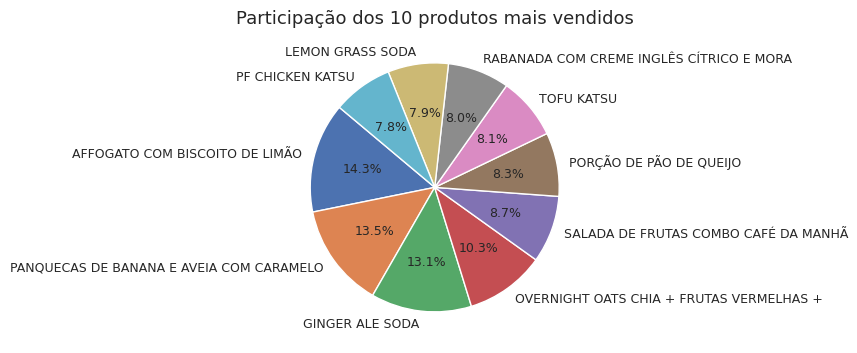

In [21]:
share = df["recipe_id"].value_counts(normalize=True).head(10) * 100

fig, ax = plt.subplots(figsize=(8, 8))
labels = [produtos.set_index("recipe_id").loc[i, "produto"][:40] for i in share.index]
ax.pie(share.values, labels=labels, autopct="%1.1f%%", startangle=140, textprops={"fontsize": 9})
ax.set_title("Participação dos 10 produtos mais vendidos")
plt.tight_layout()
plt.show()

## 7. Quantidade por venda

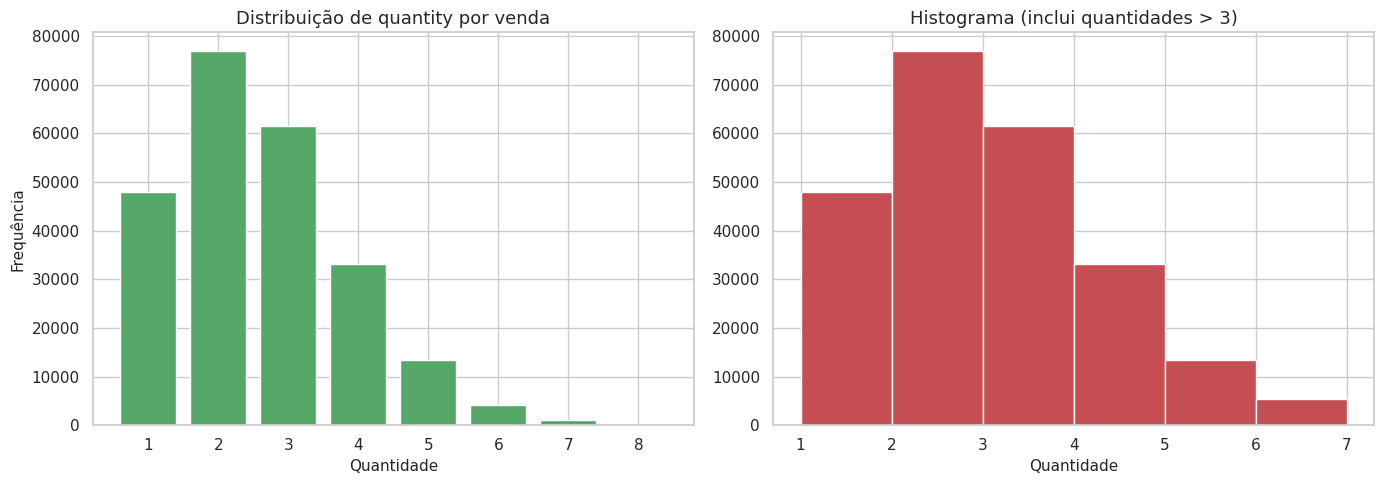

count    238582.000000
mean          2.604144
std           1.265597
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max           8.000000
Name: quantity, dtype: float64


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

qtd_counts = df["quantity"].value_counts().sort_index()
axes[0].bar(qtd_counts.index.astype(str), qtd_counts.values, color=sns.color_palette("deep")[2])
axes[0].set_title("Distribuição de quantity por venda")
axes[0].set_xlabel("Quantidade")
axes[0].set_ylabel("Frequência")

axes[1].hist(df["quantity"], bins=range(1, 8), edgecolor="white", color=sns.color_palette("deep")[3])
axes[1].set_title("Histograma (inclui quantidades > 3)")
axes[1].set_xlabel("Quantidade")

plt.tight_layout()
plt.show()

print(df["quantity"].describe())

## 8. Feriados e eventos (sazonalidade Recife)

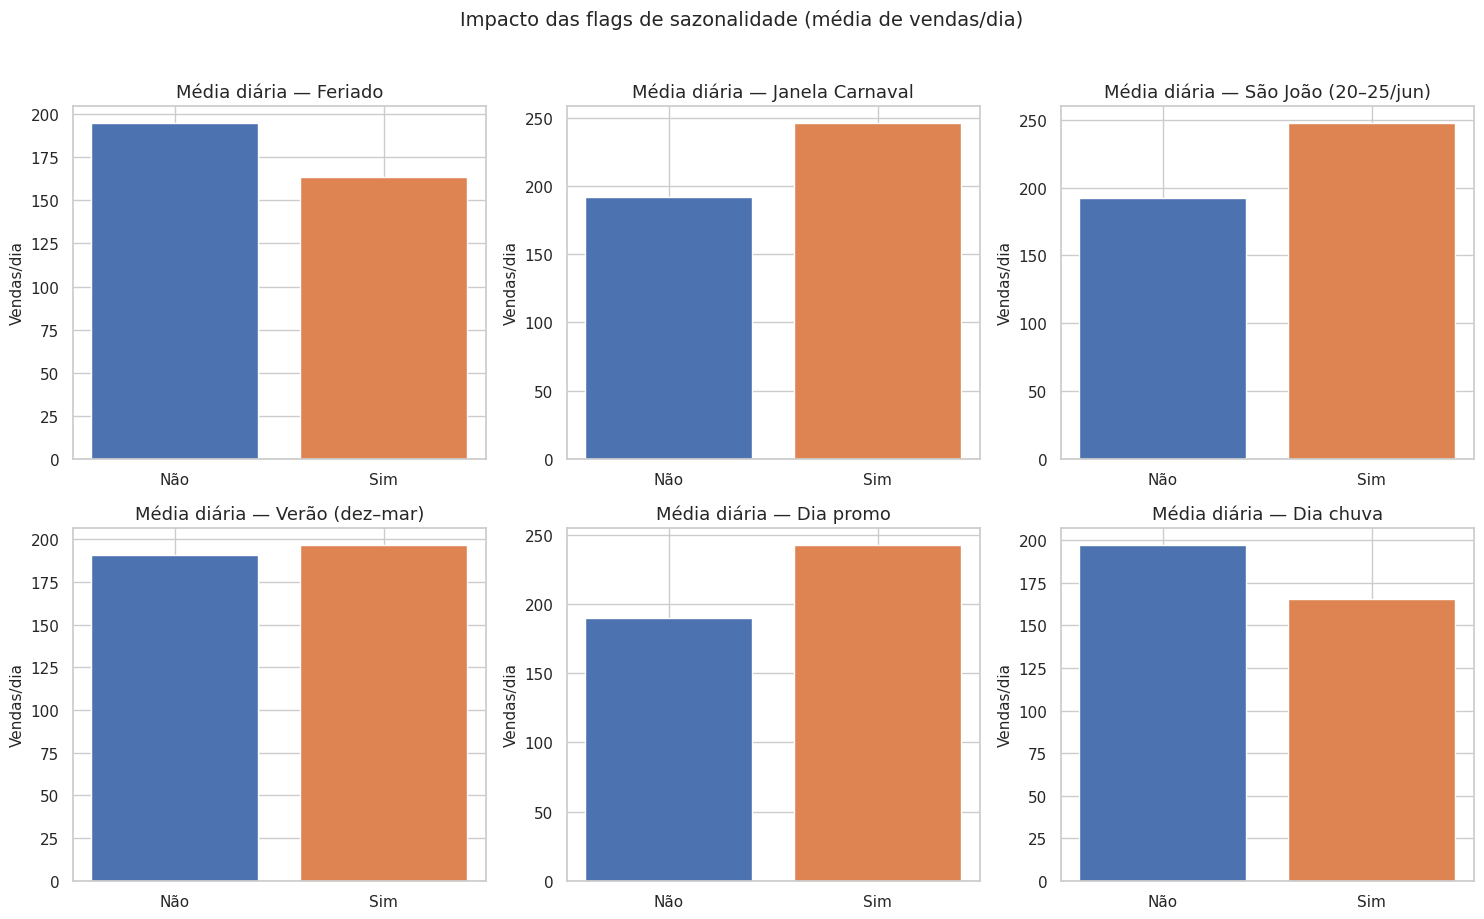

In [23]:
rd = resumo_diario.copy().rename(columns={"vendas_dia": "vendas"})

flags = [
    ("is_holiday", "Feriado"),
    ("is_carnaval_window", "Janela Carnaval"),
    ("is_sao_joao", "São João (20–25/jun)"),
    ("is_summer", "Verão (dez–mar)"),
    ("is_promo_day", "Dia promo"),
    ("is_rain_event", "Dia chuva"),
    ("is_closure", "Fechamento"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (col, titulo) in zip(axes, flags):
    stats = rd.groupby(col)["vendas"].mean()
    labels = ["Não", "Sim"] if len(stats) == 2 else stats.index.astype(str)
    ax.bar(labels[: len(stats)], stats.values, color=["#4C72B0", "#DD8452"][: len(stats)])
    ax.set_title(f"Média diária — {titulo}")
    ax.set_ylabel("Vendas/dia")

plt.suptitle("Impacto das flags de sazonalidade (média de vendas/dia)", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 9. Evolução do mix — participação dos top 5 produtos ao longo do tempo

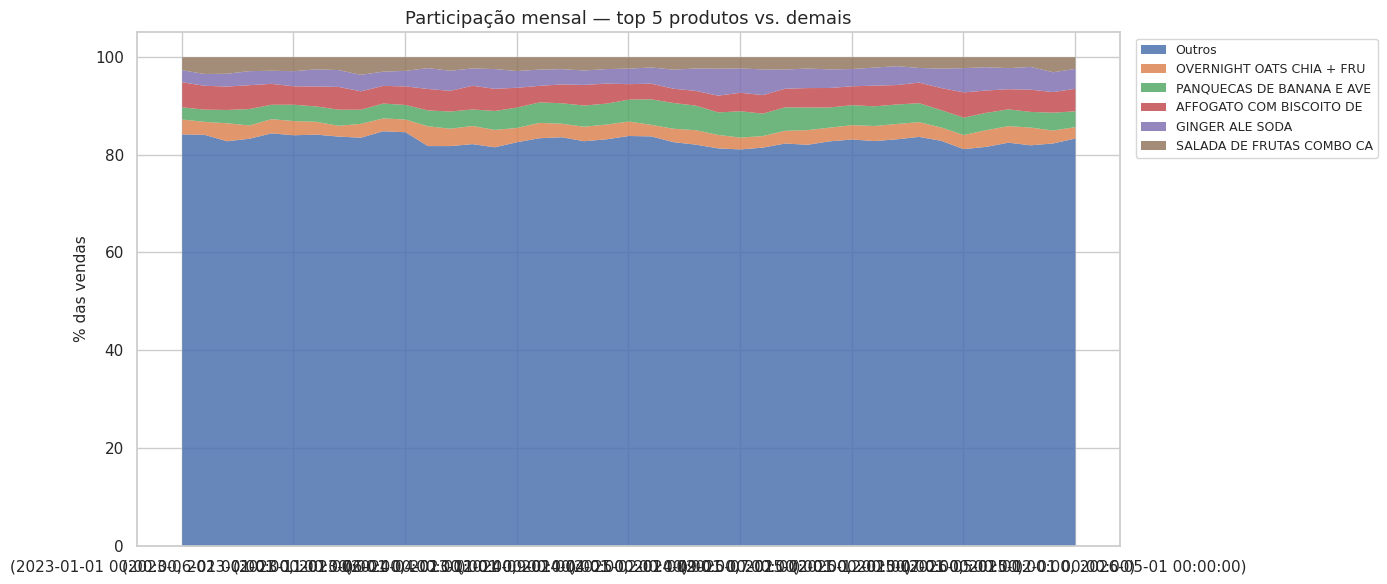

In [24]:
top5_ids = df["recipe_id"].value_counts().head(5).index.tolist()
df["top5"] = np.where(df["recipe_id"].isin(top5_ids), df["recipe_id"], "Outros")

mix_mensal = (
    df.assign(periodo=df["date_time"].dt.to_period("M").dt.to_timestamp())
    .groupby(["periodo", "top5"])["id"].count()
    .groupby(level=0)
    .apply(lambda x: x / x.sum() * 100)
    .unstack(fill_value=0)
)

mix_mensal.columns = [
    produtos.set_index("recipe_id").loc[c, "produto"][:25] if c != "Outros" else "Outros"
    for c in mix_mensal.columns
]

fig, ax = plt.subplots(figsize=(14, 6))
mix_mensal.plot.area(ax=ax, alpha=0.85, linewidth=0)
ax.set_title("Participação mensal — top 5 produtos vs. demais")
ax.set_ylabel("% das vendas")
ax.set_xlabel("")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)
plt.tight_layout()
plt.show()